In [1]:
import pandas as pd
import numpy as np
import joblib
import plotnine as pn
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import GridSearchCV
import kagglehub
from kagglehub import KaggleDatasetAdapter
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
pn.options.figure_size = (12, 8)

In [2]:
import os

# Download the dataset
path = kagglehub.dataset_download("woody123/cdnow-dataset")

print("Files in the downloaded dataset:")
for root, _, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))
        path = os.path.join(root, file)

df = pd.read_csv(path)
df.shape

100%|██████████| 576k/576k [00:00<00:00, 33.1MB/s]

Extracting files...
Files in the downloaded dataset:
/root/.cache/kagglehub/datasets/woody123/cdnow-dataset/versions/1/cdnow.csv


(69659, 5)

Prepare data

In [3]:
df.head()
df.columns

Index(['Unnamed: 0', 'customer_id', 'date', 'quantity', 'price'], dtype='object')

In [4]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [5]:
df.dtypes

,0
customer_id,int64
date,object
quantity,int64
price,float64


In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.dtypes

,0
customer_id,int64
date,datetime64[ns]
quantity,int64
price,float64


In [8]:
df.head()

,customer_id,date,quantity,price
0,1,1997-01-01,1,11.77
1,2,1997-01-12,1,12.00
2,2,1997-01-12,5,77.00
3,3,1997-01-02,2,20.76
4,3,1997-03-30,2,20.76


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  69659 non-null  int64         
 1   date         69659 non-null  datetime64[ns]
 2   quantity     69659 non-null  int64         
 3   price        69659 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 2.1 MB


In [10]:
df.isnull().sum()

,0
customer_id,0
date,0
quantity,0
price,0


In [11]:
df_first_purchase = df.groupby('customer_id').first()
df_first_purchase

,date,quantity,price
customer_id,,,
1,1997-01-01,1,11.77
2,1997-01-12,1,12.00
3,1997-01-02,2,20.76
4,1997-01-01,2,29.33
5,1997-01-01,2,29.33
...,...,...,...
23566,1997-03-25,2,36.00
23567,1997-03-25,1,20.97
23568,1997-03-25,1,22.97


In [12]:
df_first_purchase.date.min()

Timestamp('1997-01-01 00:00:00')

In [13]:
df_first_purchase.date.max()

Timestamp('1997-03-25 00:00:00')

<Axes: xlabel='date'>

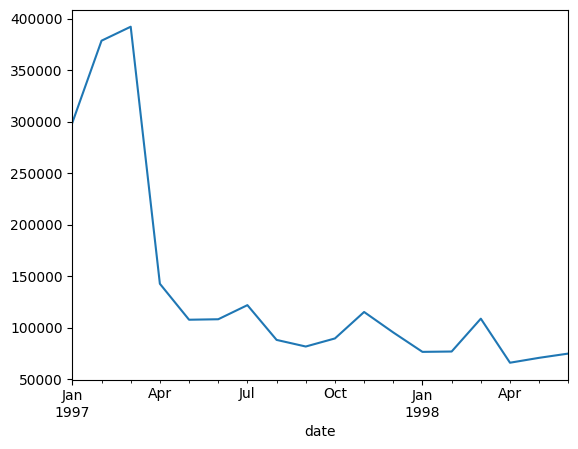

In [14]:
df.reset_index().set_index('date')['price'].resample(rule = 'MS').sum().plot()

In [15]:
ids = df['customer_id'].unique()
ids_selected = ids[0:10]
ids_selected

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [16]:
df_cust_id_subset = df[df['customer_id'].isin(ids_selected)].groupby(['customer_id', 'date']).sum().reset_index()

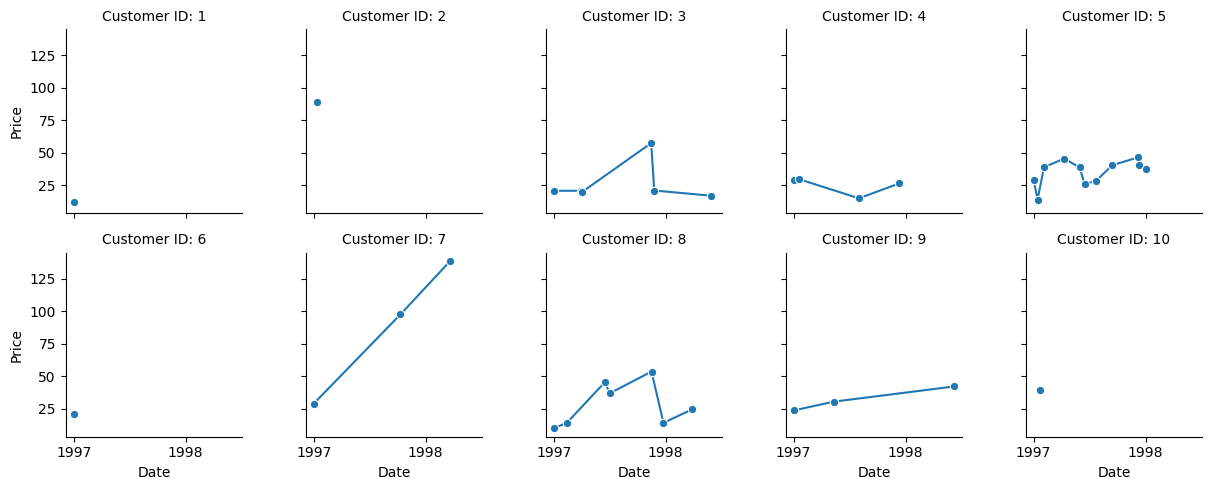

In [17]:
g = sns.FacetGrid(
    df_cust_id_subset, col="customer_id", col_wrap=5, height=2.5, aspect=1
)
g.map_dataframe(sns.lineplot, x="date", y="price", marker="o")
g.set_titles("Customer ID: {col_name}")
g.set_axis_labels("Date", "Price")

# format all x-axes to show only years
for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.show()

Machine Learning
- What will the customer spend in the next 90-Days? (Regression)
- What is the probability of a customer to make a purchase in next 90-days? (Classification)

In [18]:
n_days = 90
max_date = df.date.max()
cutoff = max_date - pd.Timedelta(days = n_days)


In [19]:
temporal_in_df = df[df.date <= cutoff]

In [20]:
temporal_out_df = df[df.date > cutoff]

RFM

In [21]:
targets_df = temporal_out_df.drop('quantity', axis=1)\
.groupby('customer_id')\
.sum(numeric_only=True)\
.rename({'price':'spend_90_total'}, axis=1)\
.assign(spend_90_flag = 1)
targets_df.head()

,spend_90_total,spend_90_flag
customer_id,,
3,16.99,1
9,41.98,1
25,73.43,1
29,48.45,1
31,117.99,1


In [22]:
max_date = temporal_in_df.date.max()

In [23]:
recency_faetures_df = temporal_in_df[['customer_id', 'date']]\
.groupby('customer_id').apply(
    lambda x: (x.date.max() - max_date) / pd.Timedelta(days = 1)
)\
.to_frame('recency')
recency_faetures_df.head()

/tmp/ipython-input-2764775821.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,recency
customer_id,
1,-455.0
2,-444.0
3,-127.0
4,-110.0
5,-88.0


In [24]:
frequency_features_df = temporal_in_df[['customer_id', 'date']]\
.groupby('customer_id')\
.count()\
.rename({'date':'frequency'}, axis=1)
frequency_features_df.head()

,frequency
customer_id,
1,1
2,2
3,5
4,4
5,11


In [25]:
price_featuers_df = temporal_in_df\
.groupby('customer_id')\
.aggregate(
    {
        'price': ['sum','mean']
    }
)\
.set_axis(['price_sum', 'price_mean'], axis=1)
price_featuers_df.head()

,price_sum,price_mean
customer_id,,
1,11.77,11.770000
2,89.00,44.500000
3,139.47,27.894000
4,100.50,25.125000
5,385.61,35.055455


In [26]:
features_df = pd.concat([recency_faetures_df, frequency_features_df, price_featuers_df], axis=1)\
.merge(
    targets_df, how='left', left_index=True, right_index=True
)\
.fillna(0)

features_df.head()

,recency,frequency,price_sum,price_mean,spend_90_total,spend_90_flag
customer_id,,,,,,
1,-455.0,1,11.77,11.770000,0.00,0.0
2,-444.0,2,89.00,44.500000,0.00,0.0
3,-127.0,5,139.47,27.894000,16.99,1.0
4,-110.0,4,100.50,25.125000,0.00,0.0
5,-88.0,11,385.61,35.055455,0.00,0.0


Training machine learning model

In [27]:
X = features_df.drop(['spend_90_total','spend_90_flag'], axis=1)
y_spend = features_df.spend_90_total

In [28]:
xgb_reg_spec = XGBRegressor(
    objective='reg:squarederror',
    random_state = 123
)

In [29]:
xgb_reg_model = GridSearchCV(
    estimator = xgb_reg_spec,
    param_grid = dict(
        learning_rate = [0.01, 0.1, 0.3, 0.5]
    ),
    scoring = 'neg_mean_absolute_error',
    refit = True,
    cv = 5
)


In [30]:
xgb_reg_model.fit(X, y_spend)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.3, 0.5]},
             scoring='neg_mean_absolute_error')

In [31]:
xgb_reg_model.best_score_

np.float64(-10.939501193931802)

In [32]:
xgb_reg_model.best_params_

{'learning_rate': 0.1}

In [33]:
xgb_reg_model.best_estimator_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
predictions_reg = xgb_reg_model.predict(X)
predictions_reg

array([ 0.8516166,  2.0874057, 12.327984 , ...,  4.558194 ,  1.140923 ,
        3.5550523], dtype=float32)

In [35]:
y_prob = features_df['spend_90_flag']

In [36]:
xgb_clf_spec = XGBClassifier(
    objective='binary:logistic',
    random_state = 123
)

In [37]:
xgb_clf_model = GridSearchCV(
    estimator = xgb_clf_spec,
    param_grid = dict(
        learning_rate = [0.01, 0.1, 0.3, 0.5]
    ),
    scoring = 'roc_auc',
    refit= True,
    cv = 5
)

In [38]:
xgb_clf_model.fit(X, y_prob)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.3, 0.5]},
             scoring='roc_auc')

In [39]:
xgb_clf_model.best_score_

np.float64(0.8343151960151758)

In [40]:
xgb_clf_model.best_params_

{'learning_rate': 0.01}

In [41]:
xgb_clf_model.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [42]:
predictions_clf = xgb_clf_model.predict_proba(X)
predictions_clf

array([[0.93303406, 0.06696593],
       [0.93894994, 0.06105003],
       [0.7778516 , 0.22214845],
       ...,
       [0.8863402 , 0.11365979],
       [0.92640376, 0.07359624],
       [0.90260196, 0.09739803]], dtype=float32)

In [43]:
imp_spend_amount_dict = xgb_reg_model.best_estimator_.get_booster().get_score(importance_type='gain')

imp_spend_amount_dict


{'recency': 21092.818359375,
 'frequency': 73742.4453125,
 'price_sum': 135610.15625,
 'price_mean': 30542.48828125}

In [44]:
imp_spend_amount_df = pd.DataFrame(imp_spend_amount_dict.items(), columns=['feature', 'importance'])
imp_spend_amount_df

,feature,importance
0,recency,21092.818359
1,frequency,73742.445312
2,price_sum,135610.156250
3,price_mean,30542.488281


<Axes: xlabel='feature'>

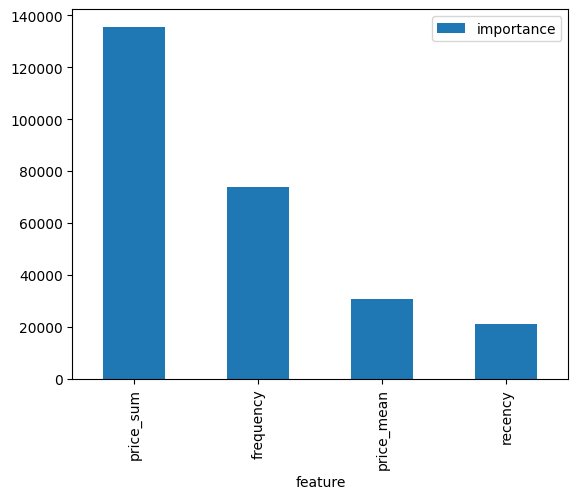

In [45]:
imp_spend_amount_df.sort_values('importance', ascending=False).plot(kind='bar', x='feature', y='importance')

In [46]:
imp_spend_prob_dict = xgb_clf_model.best_estimator_.get_booster().get_score(importance_type='gain')
imp_spend_prob_dict = pd.DataFrame(imp_spend_prob_dict.items(), columns=['feature', 'importance'])
imp_spend_prob_dict

,feature,importance
0,recency,92.591789
1,frequency,57.711456
2,price_sum,3.046099
3,price_mean,3.167080


<Axes: xlabel='feature'>

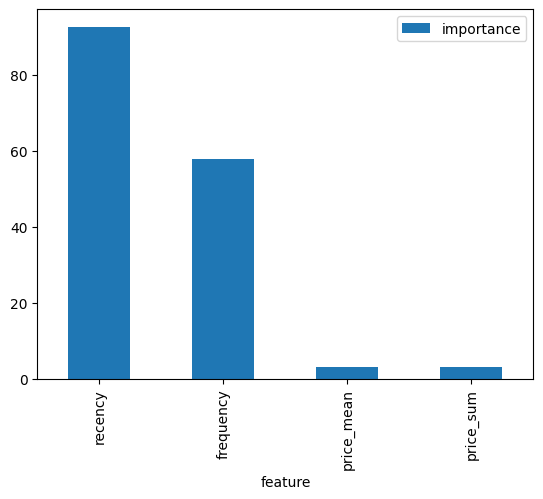

In [47]:
imp_spend_prob_dict.sort_values('importance', ascending=False).plot(kind='bar', x='feature', y='importance')

In [48]:
predictions_df = pd.concat(
    [
        pd.DataFrame(predictions_reg, columns=['pred_spend']),
        pd.DataFrame(predictions_clf[:,1], columns=['pred_prob']),
        features_df.reset_index()
    ],
    axis=1
)
predictions_df.head()

,pred_spend,pred_prob,customer_id,recency,frequency,price_sum,price_mean,spend_90_total,spend_90_flag
0,0.851617,0.066966,1,-455.0,1,11.77,11.770000,0.00,0.0
1,2.087406,0.061050,2,-444.0,2,89.00,44.500000,0.00,0.0
2,12.327984,0.222148,3,-127.0,5,139.47,27.894000,16.99,1.0
3,10.697600,0.219153,4,-110.0,4,100.50,25.125000,0.00,0.0
4,29.300179,0.428219,5,-88.0,11,385.61,35.055455,0.00,0.0


Wich customer have the highest spend probability in next 90-days?
- target for new products similar to what they have purshed in the past

In [51]:
predictions_df.sort_values('pred_prob', ascending=False)

,pred_spend,pred_prob,customer_id,recency,frequency,price_sum,price_mean,spend_90_total,spend_90_flag
13166,336.888397,0.623349,13167,-3.0,47,3563.95,75.828723,334.75,1.0
3618,209.024139,0.623349,3619,-3.0,20,903.35,45.167500,136.44,1.0
12859,431.955383,0.623349,12860,-3.0,30,1389.08,46.302667,457.26,1.0
5609,152.623322,0.623349,5610,-3.0,20,1449.22,72.461000,132.23,1.0
7273,80.264366,0.623349,7274,-1.0,24,725.78,30.240833,49.48,1.0
...,...,...,...,...,...,...,...,...,...
5244,2.096353,0.061050,5245,-428.0,2,88.21,44.105000,0.00,0.0
4644,2.096353,0.061050,4645,-428.0,2,85.96,42.980000,0.00,0.0
20,1.894441,0.061050,21,-443.0,2,75.11,37.555000,0.00,0.0
1,2.087406,0.061050,2,-444.0,2,89.00,44.500000,0.00,0.0


Which customer have recently purchased but are unlikely to buy?
- incentivize actions to inrease probability
- provide discounts, encourage referring a fried, nurture by letting them know what's coming


In [52]:
predictions_df[predictions_df.recency>-90][predictions_df.pred_prob<0.2].sort_values('pred_prob', ascending=False)

/tmp/ipython-input-4269370644.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


,pred_spend,pred_prob,customer_id,recency,frequency,price_sum,price_mean,spend_90_total,spend_90_flag
12762,7.533930,0.199274,12763,-85.0,3,74.21,24.736667,0.00,0.0
23085,9.976034,0.199004,23086,-89.0,3,78.84,26.280000,53.47,1.0
4952,16.727982,0.198885,4953,-58.0,3,185.39,61.796667,0.00,0.0
1489,16.127047,0.198885,1490,-67.0,3,193.88,64.626667,0.00,0.0
1003,20.016394,0.198885,1004,-59.0,3,257.88,85.960000,0.00,0.0
...,...,...,...,...,...,...,...,...,...
3928,2.821583,0.115086,3929,-8.0,2,229.17,114.585000,0.00,0.0
15504,14.595891,0.111638,15505,-20.0,2,215.33,107.665000,0.00,0.0
16100,14.595891,0.111638,16101,-23.0,2,213.62,106.810000,0.00,0.0
6971,14.764078,0.111638,6972,-23.0,2,191.94,95.970000,0.00,0.0


Missed opportunities: Big spender that could be unlock
- send bundle offers encouraging voulem purchases
- focus on missed opportunities

In [53]:
predictions_df[predictions_df.spend_90_total==0.0].sort_values('pred_prob', ascending=False)

,pred_spend,pred_prob,customer_id,recency,frequency,price_sum,price_mean,spend_90_total,spend_90_flag
7322,85.233147,0.615844,7323,-10.0,22,827.28,37.603636,0.0,0.0
5054,113.941353,0.615844,5055,-8.0,20,797.11,39.855500,0.0,0.0
4158,32.954739,0.593795,4159,-4.0,36,931.68,25.880000,0.0,0.0
17522,117.985970,0.591230,17523,-5.0,17,2280.08,134.122353,0.0,0.0
10612,57.533554,0.590737,10613,-3.0,13,523.72,40.286154,0.0,0.0
...,...,...,...,...,...,...,...,...,...
459,2.440753,0.061050,460,-434.0,2,64.96,32.480000,0.0,0.0
5287,2.024662,0.061050,5288,-426.0,2,103.26,51.630000,0.0,0.0
5307,1.894441,0.061050,5308,-435.0,2,74.93,37.465000,0.0,0.0
5500,1.753985,0.061050,5501,-434.0,2,98.69,49.345000,0.0,0.0
